### 1. Importações

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

### 2. Carregamento dos dados

In [2]:
df = pd.read_parquet("d:/FIAP/Engenharia de Machine Learning/Fase 3/tech_challenge_3/data/processed/flights_processed.parquet")
#pd.set_option('display.max_columns', None) 
#df.head() #ou df.sample() para ver dados aleatórios

In [4]:
print("Shape do dataset:")
print(df.shape)

print("\nInformações gerais:")
print(df.info())

Shape do dataset:
(5222000, 47)

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 5222000 entries, 0 to 5221999
Data columns (total 47 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   AIRLINE                    category      
 1   YEAR                       int16         
 2   MONTH                      int8          
 3   DAY                        int8          
 4   DAY_OF_WEEK                int8          
 5   AIRLINE_CODE               str           
 6   FLIGHT_NUMBER              int32         
 7   TAIL_NUMBER                category      
 8   ORIGIN_AIRPORT             str           
 9   DESTINATION_AIRPORT        str           
 10  SCHEDULED_DEPARTURE        int16         
 11  DEPARTURE_DELAY            float32       
 12  SCHEDULED_TIME             float32       
 13  DISTANCE                   int16         
 14  SCHEDULED_ARRIVAL          int16         
 15  ORIGIN_AIRPORT_NAME        str           

### 3. Análise exploratória

###  3.1 Balanceamento do target

* Os dados estão numa proporção 80/20. 
* É esperado que os dados estejam desbalanceados, porque a maioria dos voos não atrasa.
* O problema é que um modelo ingênuo poderia prever sempre 0 e ainda ter cerca de 80% de acurácia. (e, por isso, accuracy sozinha não é boa métrica)
* Com 5,2 milhões de linhas, já há muitos exemplos da classe minoritária (cerca de 1 milhão).

In [12]:
print("\nDistribuição do target:")
print(df["IS_DELAYED"].value_counts())

print("\nDistribuição percentual:")
print(df["IS_DELAYED"].value_counts(normalize=True) * 100)


Distribuição do target:
IS_DELAYED
0    4236846
1     989723
Name: count, dtype: int64

Distribuição percentual:
IS_DELAYED
0    81.063619
1    18.936381
Name: proportion, dtype: float64


### 3.2 Distribuição dos atrasos

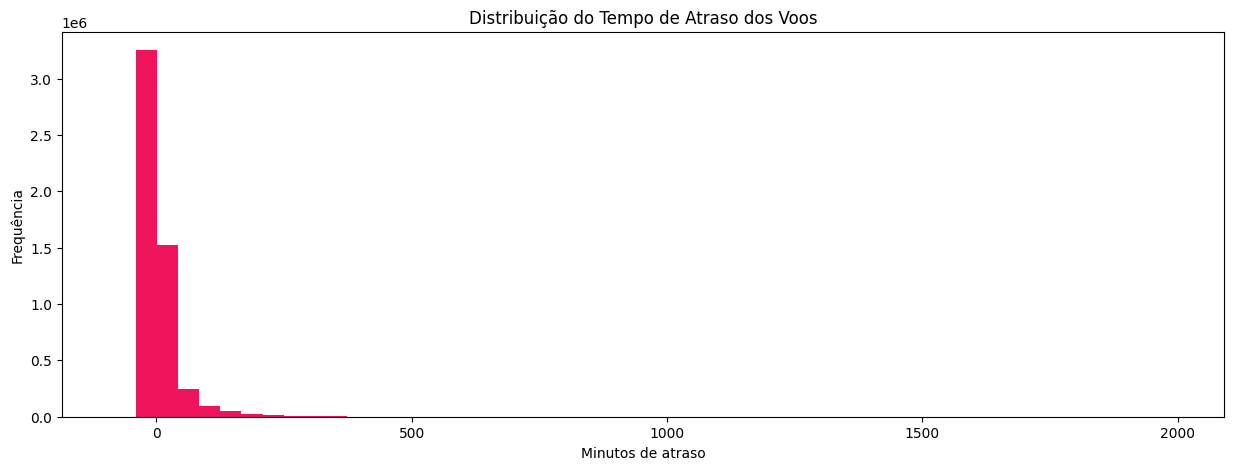

In [10]:
delay = df["DEPARTURE_DELAY"]

plt.figure(figsize=(15,5))

plt.hist(
    delay,
    bins=50,
    color="#ED145B",   # cor FIAP
)

plt.title("Distribuição do Tempo de Atraso dos Voos")
plt.xlabel("Minutos de atraso")
plt.ylabel("Frequência")

plt.show()


In [3]:
print("O maior atraso foi de ", max(df["DEPARTURE_DELAY"]), "minutos.")

In [4]:
df[df["DEPARTURE_DELAY"] > 500]["DEPARTURE_DELAY"].describe()

count    2072.000000
mean      724.474426
std       220.523483
min       501.000000
25%       554.750000
50%       654.000000
75%       831.000000
max      1988.000000
Name: DEPARTURE_DELAY, dtype: float64

ver se os atrasos estão concentrados em companhias aéreas

In [8]:
extreme_delays = df[df["DEPARTURE_DELAY"] > 500]
extreme_delays["AIRLINE_NAME"].value_counts()

AIRLINE_NAME
Delta Air Lines Inc.            544
American Airlines Inc.          536
Skywest Airlines Inc.           262
United Air Lines Inc.           180
American Eagle Airlines Inc.    156
Atlantic Southeast Airlines     131
Frontier Airlines Inc.          114
Southwest Airlines Co.           36
JetBlue Airways                  31
Alaska Airlines Inc.             27
Spirit Air Lines                 21
Hawaiian Airlines Inc.           21
US Airways Inc.                  10
Virgin America                    3
Name: count, dtype: int64

### Rotas 

Cria tabela com 50 principais rotas de atraso

In [22]:
# filtrar voos atrasados
df_delay = df[df["DEPARTURE_DELAY"] >= 15]

# calcular quantidade de atrasos por rota
routes_df = (
    df_delay.groupby(["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"])
    .agg(
        qtd_voos_atrasados=("DEPARTURE_DELAY", "size"),
        ORIGIN_LAT=("ORIGIN_LAT", "first"),
        ORIGIN_LON=("ORIGIN_LON", "first"),
        DEST_LAT=("DEST_LAT", "first"),
        DEST_LON=("DEST_LON", "first")
    )
    .reset_index()
)

# ordenar pela quantidade de atrasos
routes_df = routes_df.sort_values(
    "qtd_voos_atrasados",
    ascending=False
)

# pegar top 50
routes_df = routes_df.head(50)

In [19]:
map_routes = folium.Map(
    location=[39.5, -98.35],  # centro aproximado dos EUA
    zoom_start=4
)

for _, row in routes_df.iterrows():

    # linha da rota
    folium.PolyLine(
        [
            [row["ORIGIN_LAT"], row["ORIGIN_LON"]],
            [row["DEST_LAT"], row["DEST_LON"]]
        ],
        color="blue",
        weight=1,
        opacity=0.4
    ).add_to(map_routes)

    # marcador com seta no destino
    folium.Marker(
        location=[row["DEST_LAT"], row["DEST_LON"]],
        tooltip=f'{row["ORIGIN_AIRPORT"]} → {row["DESTINATION_AIRPORT"]}',
        icon=folium.Icon(icon="arrow-right", prefix="fa")
    ).add_to(map_routes)

map_routes


mapa de calor com todas as rotas

In [21]:
df_delay = df[df["DEPARTURE_DELAY"] >= 15]

state_delay = (
    df_delay.groupby("ORIGIN_STATE")
    .agg(
        qtd_atrasos=("DEPARTURE_DELAY","size"),
        LAT=("ORIGIN_LAT","mean"),
        LON=("ORIGIN_LON","mean")
    )
    .reset_index()
)

map_heat = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles="cartodbpositron"
)

heat_data = [
    [row["LAT"], row["LON"], row["qtd_atrasos"]]
    for _, row in state_delay.iterrows()
]

HeatMap(
    heat_data,
    radius=40,
    blur=25,
    max_zoom=6
).add_to(map_heat)

map_heat


### 3.3 Sazonalidade

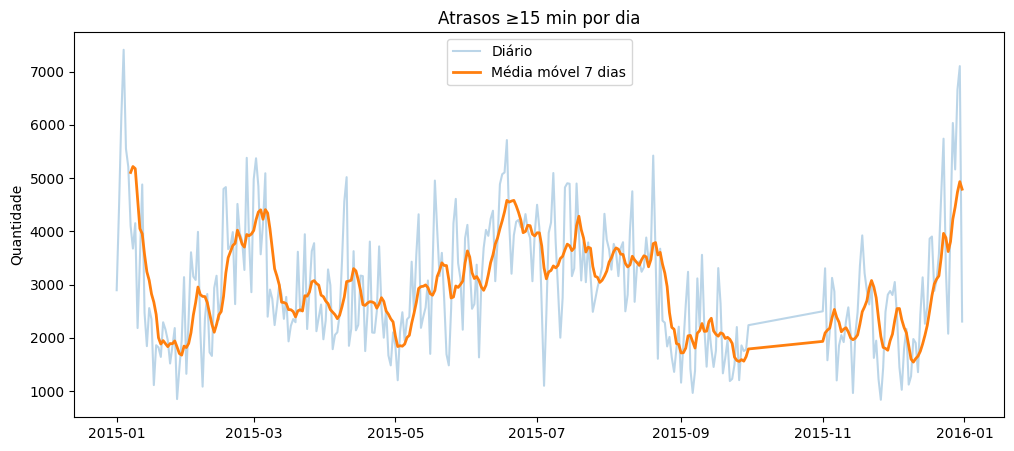

In [27]:
rolling = delay_per_day.rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(delay_per_day, alpha=0.3, label="Diário")
plt.plot(rolling, linewidth=2, label="Média móvel 7 dias")

plt.title("Atrasos ≥15 min por dia")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

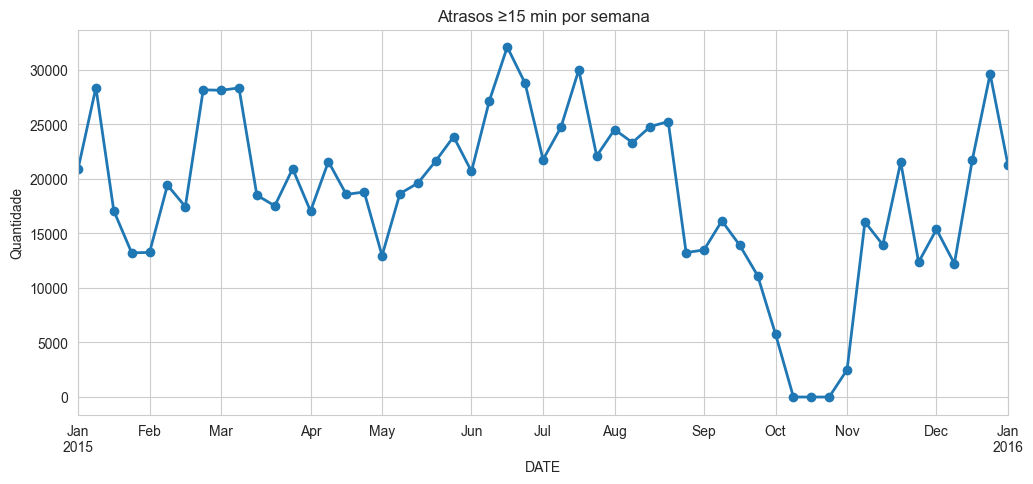

In [31]:
delay_per_week = (
    df[df["DEPARTURE_DELAY"] >= 15]
    .set_index("DATE")
    .resample("W")
    .size()
)

delay_per_week.plot(figsize=(12,5), linewidth=2, kind="line",marker="o",)
plt.title("Atrasos ≥15 min por semana")
plt.ylabel("Quantidade")
plt.show()

Analisa se os atrasos estão concentrados em faixa do dia específica

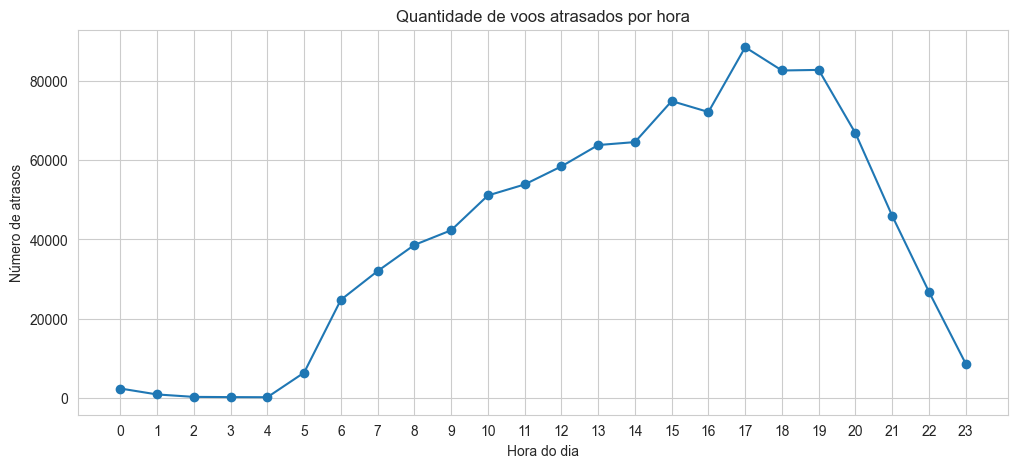

In [32]:
delay_by_hour = (
    df[df["DEPARTURE_DELAY"] >= 15]
    .set_index("HOUR")
    .size()
)

delay_by_hour.plot(
    kind="line",
    marker="o",
    figsize=(12,5)
)

plt.title("Quantidade de voos atrasados por hora")
plt.xlabel("Hora do dia")
plt.ylabel("Número de atrasos")
plt.xticks(range(24))
plt.grid(True)
plt.show()


### Atraso por companhia aérea

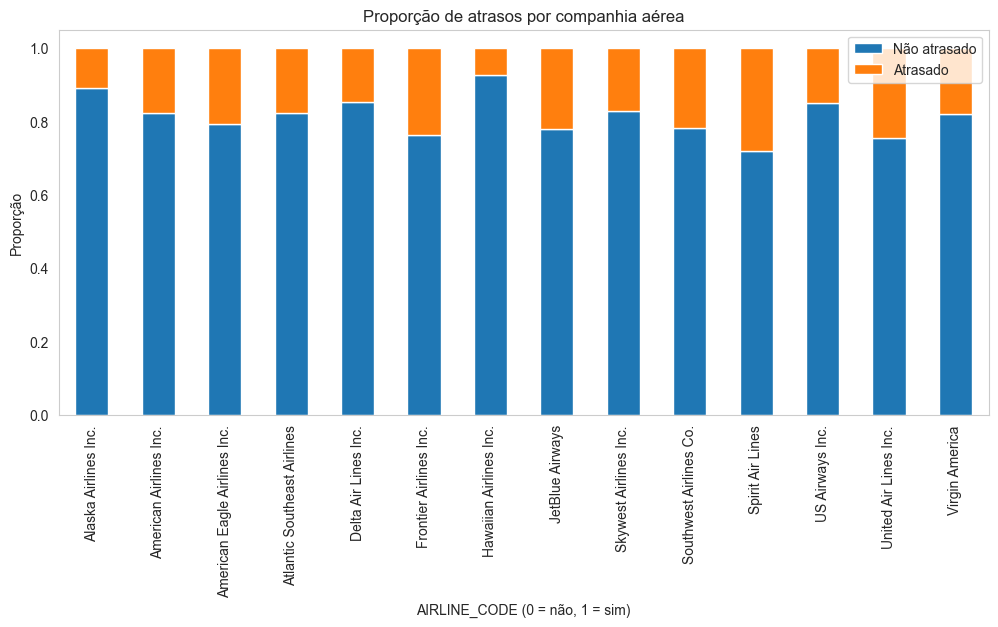

In [34]:
data = pd.crosstab(
    df["AIRLINE_NAME"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True,figsize=(12,5))

plt.title("Proporção de atrasos por companhia aérea")
plt.xlabel("AIRLINE_CODE (0 = não, 1 = sim)")
plt.ylabel("Proporção")
plt.legend(["Não atrasado", "Atrasado"])
plt.grid(False)
plt.show()

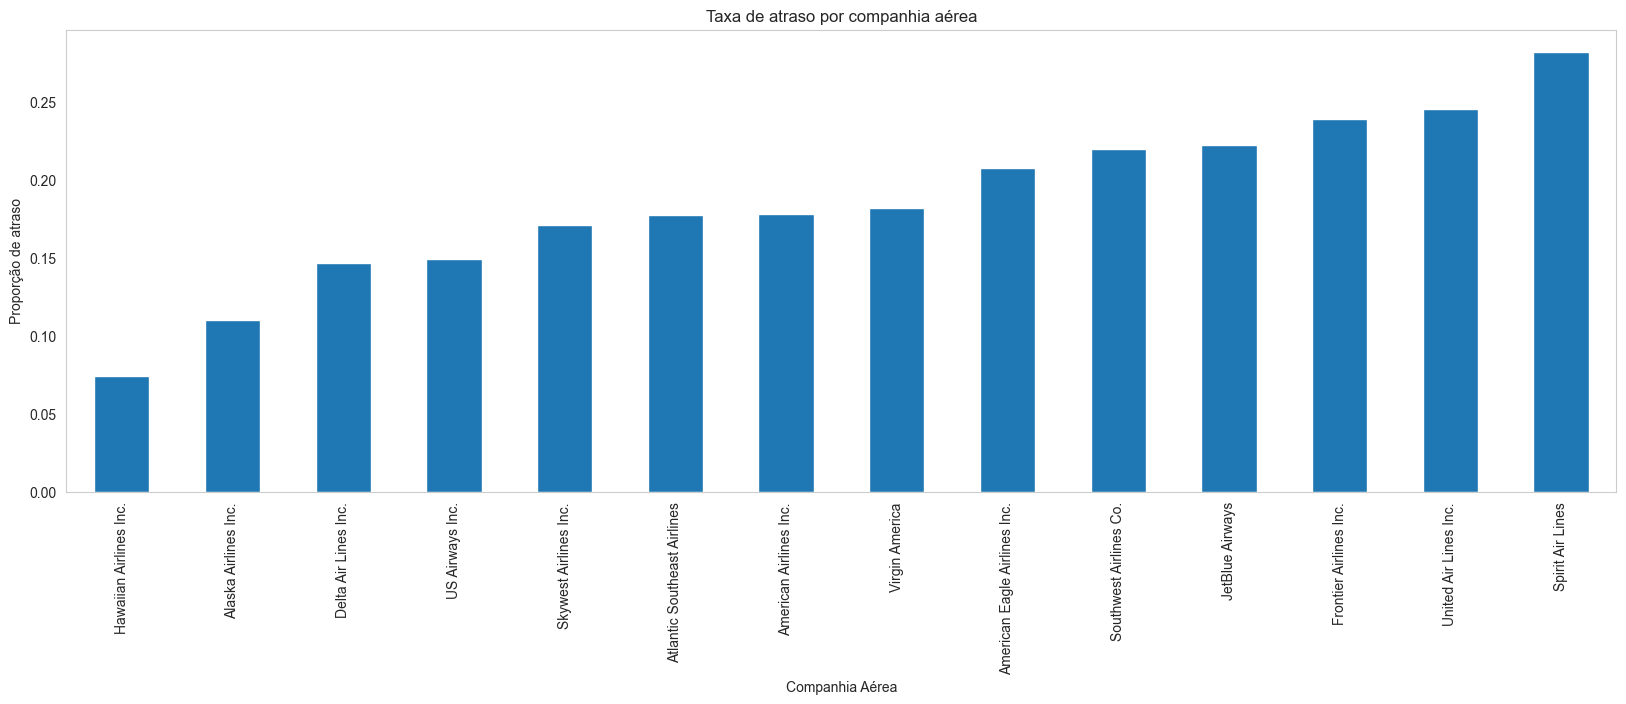

In [39]:
delay_by_state = df.groupby("AIRLINE_NAME")["IS_DELAYED"].mean().sort_values()
delay_by_state.plot(kind="bar", figsize=(20,6))
plt.title("Taxa de atraso por companhia aérea")
plt.xlabel("Companhia Aérea")
plt.ylabel("Proporção de atraso")
plt.grid(False)
plt.show()

### Atraso por distância

* Não parece ter relação com atraso

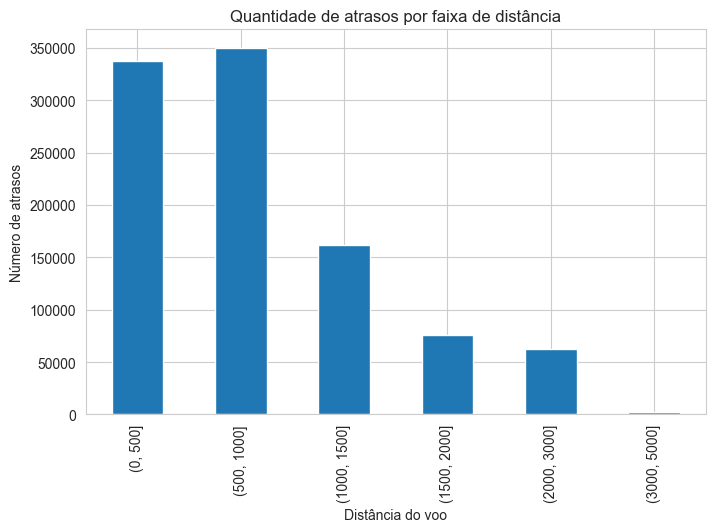

In [43]:
df_delay = df[df["DEPARTURE_DELAY"] >= 15]


# criar faixas de distância
bins = [0, 500, 1000, 1500, 2000, 3000, 5000]
df["distance_bin"] = pd.cut(df_delay["DISTANCE"], bins=bins)

# calcular quantidade de atrasos >=15
delay_distance = (
    df[df["DEPARTURE_DELAY"] >= 15]
    .groupby("distance_bin")
    .size()
)

delay_distance.plot(kind="bar", figsize=(8,5))

plt.title("Quantidade de atrasos por faixa de distância")
plt.xlabel("Distância do voo")
plt.ylabel("Número de atrasos")
plt.show()

### Atraso em feriados

* Não parece ter grande relação

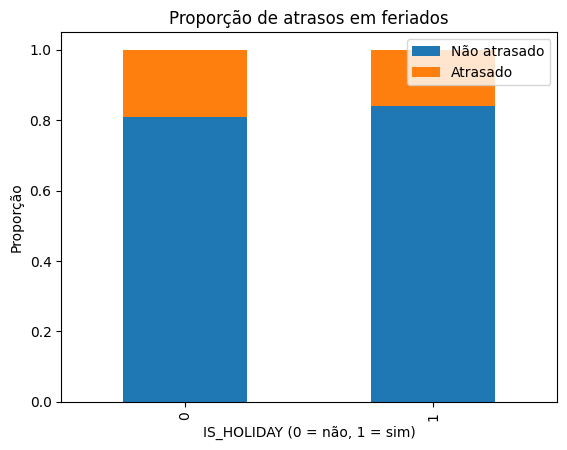

In [29]:
data = pd.crosstab(
    df["IS_HOLIDAY"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True)

plt.title("Proporção de atrasos em feriados")
plt.xlabel("IS_HOLIDAY (0 = não, 1 = sim)")
plt.ylabel("Proporção")
plt.legend(["Não atrasado", "Atrasado"])
plt.show()

### Atraso por estação do ano

* No inverno a taxa de atraso aumenta em relação ao não inverno
* primavera e verão parecem ser indiferentes
* No outono a taxa de atrasos reduzi.

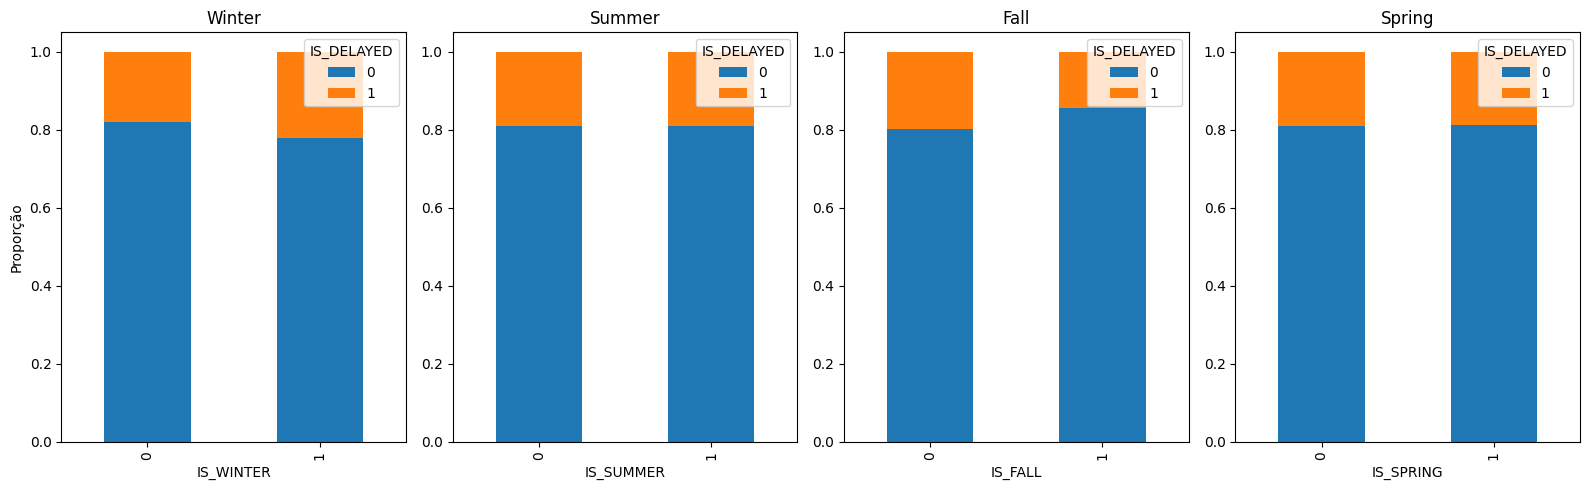

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))

# WINTER
data = pd.crosstab(
    df["IS_WINTER"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Winter")
axes[0].set_ylabel("Proporção")

# SUMMER
data = pd.crosstab(
    df["IS_SUMMER"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Summer")
axes[1].set_ylabel("")

# FALL
data = pd.crosstab(
    df["IS_FALL"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Fall")
axes[2].set_ylabel("")

#SPRING
data = pd.crosstab(
    df["IS_SPRING"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[3])
axes[3].set_title("Spring")
axes[3].set_ylabel("")


plt.tight_layout()
plt.show()

### Matriz de correlação

In [51]:
df.head(2)

,AIRLINE,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,...,DESTINATION_AIRPORT_TOP10,ORIGIN_CITY_TOP10,DEST_CITY_TOP10,ORIGIN_STATE_TOP10,DEST_STATE_TOP10,TAIL_NUMBER_TOP10,AIRLINE_TOP10,FLIGHT_NUMBER_TOP10,ROUTE,distance_bin
0,AS,2015,1,1,4,AS,98,N407AS,ANC,SEA,...,Other,Other,Other,Other,Other,Other,Other,Other,ANC-SEA,NaN
1,AA,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,...,Other,Los Angeles,Other,CA,FL,Other,AA,Other,LAX-PBI,NaN


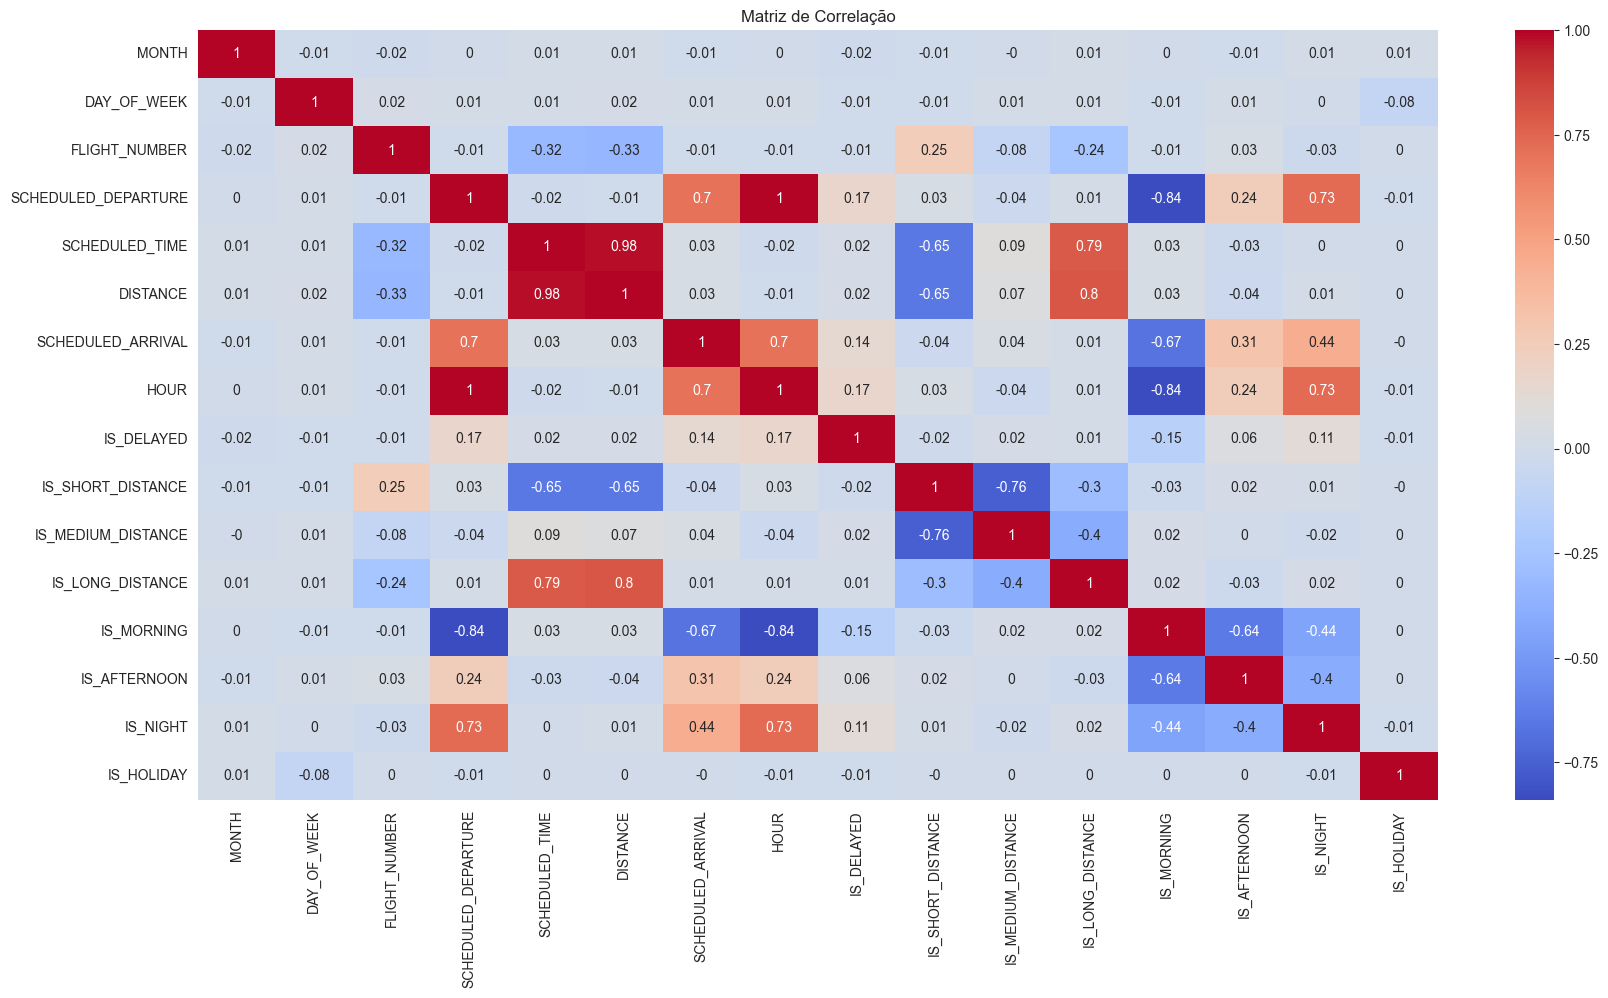

In [54]:
df_corr = df.drop(columns=["YEAR", "DAY", "ORIGIN_LAT", "ORIGIN_LON", "DEPARTURE_DELAY", "DEST_LAT", "DEST_LON", "SCHEDULED_DEPARTURE_MIN"])
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(20,10))
sns.heatmap(round(corr,2), annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação")
plt.show()